# Diffusion Model (Lecture 10)

## Why Do We Need Diffusion Model?

在模仿学习（Imitation Learning / Behavior Cloning）中，**多模态行为（Multimodal Behavior）**是一个经典的难题。比如面前有一个障碍物，人类演示的数据里有一半是从左绕，一半是从右绕。如果模型使用传统的 **均方误差 (MSE) 损失函数**，它会去拟合数据的平均值，导致机器人直接向前撞上障碍物。

在 Diffusion 模型统治具身智能之前，学术界主要尝试通过以下两大类方法来解决这个问题。

### 1. 高斯混合模型 (Mixture of Gaussians, 简称 MoG / GMM)

**【基本原理】**
既然单一的高斯分布（只能拟合一个峰/一种平均行为）不行，那就让神经网络输出多个高斯分布的组合。模型不再直接输出一个动作，而是输出 $K$ 个高斯分布的**权重 (weights)、均值 (means) 和方差 (variances)**。在推理时，先根据权重采样一个具体的峰，再从该峰的分布中采样具体动作。

**【面临的痛点与局限性】**
*   **痛点一：预设峰的数量（$K$值）非常困难。**
    *   真实世界的任务非常复杂，有些场景只有1种解法，有些有2种，有些可能有10种。如果预设的 $K$ 太小，模型还是会被迫去平均不同的行为；如果 $K$ 太大，又会引入冗余和噪声。
*   **痛点二：高维空间扩展极难 (Scalability Issues)。**
    *   机器人的动作空间通常是高维的（例如7自由度的机械臂，加上夹爪就是8维甚至更高）。为了捕捉维度之间的相关性，需要预测协方差矩阵（Covariance Matrix）。高维度的协方差矩阵参数量巨大，且必须保持正定，这在深度学习中极难优化。
*   **痛点三：训练极其不稳定 (Training Instability & Mode Collapse)。**
    *   使用最大似然估计（MLE）优化 MoG 时，极易出现**数值崩溃（Numerical Instability）**。例如，某个高斯分布的方差趋近于 0 时，似然值会趋于无穷大，导致梯度爆炸。
    *   经常发生**模式坍塌（Mode Collapse）**，即模型虽然设定了多个峰，但训练到最后所有的权重都集中在某一个峰上，本质上退化成了单峰模型。

### 2. 离散化自回归模型 (Autoregressive Discretization)

**【基本原理】**
绕开连续空间回归（Regression）的难题，将连续的动作空间**强制划分为离散的网格（Bins/Tokens）**，从而把预测动作转化为一个**分类问题（Classification Problem）**，使用交叉熵损失（Cross-Entropy Loss）进行训练。
例子：把方向强制切分为“左、中、右”三个类别。面对多模态数据（向左绕和向右绕），分类器会自然地学到概率分布 `[0.5, 0, 0.5]`，从而完美避免了输出“中（平均值）”的问题。为了处理多维动作之间的依赖关系，通常需要使用**自回归（Autoregressive）**方式（先预测关节1，再根据关节1预测关节2……）。

**【面临的痛点与局限性】**
*   **痛点一：分类损失忽略了物理度量 / 类别平权 (Metric Unawareness)。**
    *   在交叉熵分类器眼中，所有的类别（格子）都是互相独立且平权的。假设真实动作是 `Bin 50`。如果模型预测了相邻的 `Bin 51`（物理上极微小的误差），或者预测了完全相反的 `Bin 100`（严重的物理错误），**交叉熵损失给出的惩罚是一模一样的**。损失函数缺乏对“物理距离相近”这一概念的认知，导致学习效率低下。
*   **痛点二：离散化误差 (Discretization Error) 与维度爆炸的死结。**
    *   如果你把空间划分得很粗（比如只分左右），精度就不够，机器人动作会非常僵硬、无法完成精细的插入任务。
    *   如果你为了提高精度，把空间划分得很细（比如每个关节分 256 个格子），那一个7自由度的机械臂的联合动作空间就会变成 $256^7$，发生灾难性的**维度爆炸**。
*   **痛点三：自回归带来的推理延迟 (Autoregressive Latency)。**
    *   由于维度太多，不能一次性预测，只能像语言模型一样“一个词一个词往外蹦”（预测维度1 $\rightarrow$ 维度2 $\rightarrow$ ... $\rightarrow$ 维度N）。这种串行计算在需要高频实时控制（如 50Hz 以上）的机器人闭环控制中，延迟是非常致命的。

## 流匹配 (Flow Matching / Rectified Flow)

*   **核心思想**：给定噪声分布 $z \sim p_{noise}$ (通常为高斯) 和数据分布 $x \sim p_{data}$。我们构造一条从 $x$ 到 $z$ 的路径，并训练网络预测这条路径的切线向量（去除噪声的方向）。

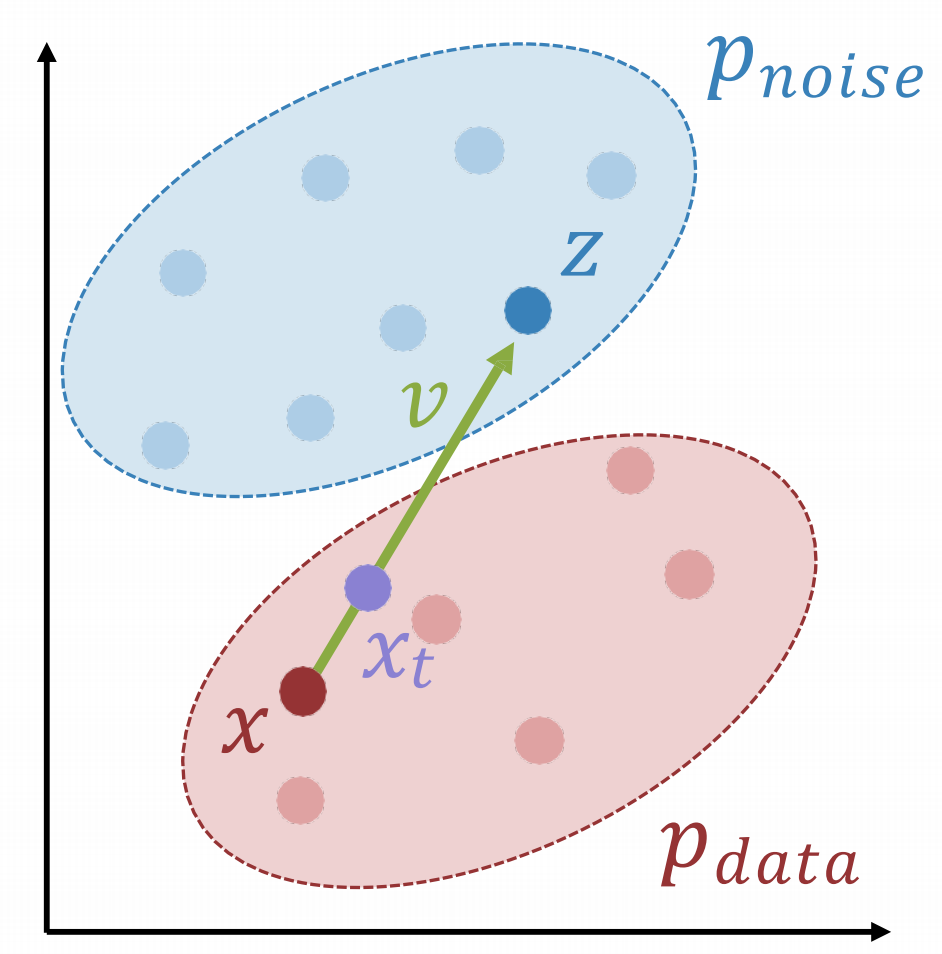

*   **训练过程 (Training)**:
    1. 采样：$z \sim p_{noise},\ x \sim p_{data},\ t \sim \text{Uniform}[0,1]$
    2. 构造插值状态：$$x_t = (1 - t)x + tz$$
    3. 目标方向向量：$$v = z - x$$（注意这里的v本质上其实类似一个速度向量，而不是位移向量）
    4. **优化目标 (Loss 公式)**：$$L = \| f_\theta(x_t, t) - v \|_2^2$$
*   **采样过程 (Sampling)** (欧拉法):
    1. 采样初始噪声 $x_1 \sim p_{noise}$ ($t=1$)
    2. 对于步数 $t$ 从 $1$ 递减到 $0$（步长为 $1/T$）：
       * 计算向量 $v_t = f_\theta(x_t, t)$
       * **状态更新公式**：$$x = x - v_t / T$$

### Flow Matching 的核心特性

#### 1. 确定性的常微分方程 (ODE) 视角与“一一映射”
*   **同空间，不同分布**：噪声 $z \sim p_{noise}$（通常是标准高斯）与真实数据 $x \sim p_{data}$ 属于完全相同的维度空间，但它们服从截然不同的概率分布。
*   **确定性去噪 (Deterministic Process)**：与传统 Diffusion 依赖随机微分方程 (SDE，去噪时会不断注入再去除随机噪声) 不同，**Flow Matching 采用常微分方程 (ODE)** 进行采样。即 “No randomness in updating”。
*   **一一映射 (Bijection)**：因为采样过程是求解一个常微分方程 $\frac{dx_t}{dt} = v_\theta(x_t, t)$，只要向量场足够平滑，给定一个特定的初始噪声 $z_0$，它就会沿着确定的轨迹流向唯一确定的数据点 $x_0$。在这个过程中，**噪声空间与数据空间形成完美的“一一映射”**，不存在任何随机扰动。这不仅减少了所需的推理步数（faster inference），也使得过程完全可逆。

#### 2. 为什么推理 (Test Time) 不能“一步到位”，必须一小步一小步走？

*   **中间状态的“多义性” (Ambiguity)**：
    *   在训练时，对于一对随机采样的 $(x, z)$，我们构建了一条由 $x$ 指向 $z$ 的直线路径，状态点为 $x_t$。
    *   但在高维空间中，**同一个中间状态点 $x_t$，可能同时属于无数条不同 $(x, z)$ 组合的路径**（想象一下无数条线段在中间某个位置发生交叉）。
*   **模型到底学到了什么？(The "Average" Vector)**：
    *   因为同一个 $x_t$ 对应着无数个可能的目标方向（向量 $v=z-x$），而模型使用的是均方误差 (MSE) Loss 进行训练。
    *   根据 MSE 的数学性质，对于给定输入 $x_t$，**最优的预测结果 $v_\theta(x_t, t)$ 是所有经过该点的真实向量的“期望值”（即数学上的平均向量 Average Vector）**。
*   **为什么不能一步跨越？**
    *   单独看一对 $(x, z)$，它们之间确实是一条直线。但当模型对所有交叉路径求平均后，**最终学到的全局向量场 (Vector Field) 就变成了一条“曲线”**。
    *   如果在 Test time 试图从 $z$ 处“一步跨到” $x$（步长 $\Delta t = 1$），相当于顺着起点的切线方向直接走一条长长的直线。由于真实的流形是弯曲的，这种“一步迈大步”会导致严重的**积分误差 (Integration Error)**，模型最终会落在一个均值化的、模糊的、甚至不符合物理规律的错误空间中（又回到了最初想解决的 MSE 导致多模态失败的问题）。
    *   **结论**：因此，推理时必须使用 ODE 求解器（如欧拉法），**一小步一小步地更新（evaluate $v_t$, step $x = x - v_t/T$），不断修正方向，沿着弯曲的向量场平滑地“流向”真实的数据流形**。


### 可控生成与条件引导

#### 1. 条件流匹配 (Conditional Flow Matching)
*   将条件 $y$（如用户输入、图像观测）加入模型：$v = f_\theta(x_t, y, t)$。

#### 2. 无分类器引导 (Classifier-Free Guidance, CFG) 
*   **作用**：控制模型对条件 $y$ 的“强调程度”，是高质量生成的关键（广泛用于实践）。
*   **为什么叫无分类器？** 因为早期方法需要训练一个额外的分类器 $\nabla_x \log p(y|x)$ 来引导，而 CFG 用一个模型同时学习条件和无条件分布。
*   **训练 (Training)**：以一定概率（如50%）**随机丢弃条件 $y$**（设为空 $y_\emptyset$）。
*   **采样 (Sampling) 公式**：
    1. 计算无条件预测：$v^\emptyset = f_\theta(x_t, y_\emptyset, t)$（指向 $p(x)$）
    2. 计算有条件预测：$v^y = f_\theta(x_t, y, t)$（指向 $p(x|y)$）
    3. **CFG 引导公式**：$$v^{cfg} = (1 + w)v^y - w v^\emptyset$$
    *(其中 $w$ 为引导强度权重。$v^{cfg}$ 将更强烈地指向符合条件 $y$ 的区域)*
*   **缺点**：每次推理需要前向传播两次（无条件和有条件），**使得采样成本翻倍**。

### 噪声调度 (Noise Schedules)
*   问题：由于 $t=1$（全噪声）和 $t=0$（无噪声）的预测很容易（分别是数据均值和噪声均值），而中间噪声 (Middle noise) 最困难且模棱两可。
*   **解决方案**：采用**非均匀噪声调度**（如 Logit-normal sampling），对中间噪声给予更多的权重（Put more emphasis on middle noise）。对于高分辨率数据，还需要将噪声分布向更高噪声偏移。

## 扩散模型 (Diffusion Model) 

### 数学本质
*   **得分函数 (Score Function)**：扩散模型本质上是在学习数据分布 $p(x)$ 的得分函数 $s(x) = \nabla_x \log p(x)$，它是一个指向高概率密度区域的向量场。
*   **随机微分方程 (SDE)**：扩散的连续加噪过程可描述为 $dx = f(x,t)dt + g(t)dw$。模型训练其实是在近似求解其逆向 SDE。

### 为什么流匹配/扩散模型无法直接使用 PPO？

#### 1. PPO 算法的“胃口”：它需要什么？
在传统的强化学习（比如让机器人走路的 MLP 网络，或者 LLM 输出文本）中，策略网络 $\pi_\theta(a|s)$ 的输出是非常简单直接的：
*   **连续动作（高斯策略）**：网络直接输出一个均值 $\mu$ 和方差 $\sigma$。动作 $a$ 的概率密度 $p(a|s)$ 就是一个标准的高斯分布公式。
*   **离散动作（LLM）**：网络输出一个 Softmax 概率分布，$p(a|s)$ 就是字典里某个词的概率值。

因为公式写得出来（有**闭式解 Closed-form**），所以我们可以极快地计算出 $\log \pi_\theta(a|s)$，并且能轻松地对神经网络的参数 $\theta$ **求导（Backpropagation）**。
PPO 的核心公式里面，有一个极为关键的**概率比（Likelihood Ratio）**：
$$r(\theta) = \frac{\pi_\theta(a|s)}{\pi_{\theta_{old}}(a|s)}$$
以及计算梯度时需要的 $\nabla_\theta \log \pi_\theta(a|s)$。PPO 每一轮更新需要对成千上万个数据算这个公式，**所以计算必须极快、极其稳定**。

#### 2. 流匹配/扩散模型的“尴尬”：它给不出显式的 $p(a|s)$
到了流匹配（Flow Matching）或扩散模型这里，情况完全变了。
流匹配生成一个动作 $a$（或者叫 $x_0$），不是一步到位的，而是从一个纯噪声 $z$ 开始，经过几十上百步的 ODE（常微分方程）微小积分，**“流”**过来的。

那么，这个最终生成的动作 $a$，它的概率 $p(a|s)$ 到底是多少？
*   **在扩散模型（SDE）中**：要算最终动作的概率，你必须把中间所有可能的去噪路径全部积分（边缘化 Marginalization），这是一个高维空间上的无穷积分，**数学上根本解不出来（Intractable）**。
*   **在流匹配（ODE）中**：数学家给出了一个计算概率的公式（瞬时变量代换，Probability-flow ODE），公式如下：
    $$\log p_\theta(a|s) = \log p(z) + \int_0^1 \text{Tr}\left(\frac{\partial v_\theta(x_t, t)}{\partial x_t}\right) dt$$
    **绝望的难点就在这个公式里：**
    为了算出一个动作的概率，你不仅要求解一遍 ODE 积分，你还得求网络输出的向量 $v$ 对输入 $x_t$ 的**雅可比矩阵的迹（Jacobian-trace）**。
    *   **极度缓慢（Expensive）**：神经网络算一次输出很快，但算雅可比矩阵极其昂贵，还要沿着几十步的路径一直算，耗时是普通前向传播的几十上百倍。
    *   **极不稳定（Fragile）**：在对这么复杂的积分再求一次导数（$\nabla_\theta \log p_\theta$）时，梯度极其容易爆炸或消失（Numerically fragile gradients）。

#### 3. 形象的比喻
*   **传统模型（高斯策略/LLM）**：就像射击。网络直接告诉你“靶心在哪，误差多大”。你可以立刻用尺子量出射中某环的**确切概率**。
*   **流匹配/扩散模型**：就像走迷宫。你从一个随机入口（噪声）进去，根据墙上的箭头（网络预测的 $v$）一步一步走，最后从出口出来（动作 $a$）。现在 PPO 问你：“你从这个特定出口出来的**绝对概率**是多少？” 你必须逆推迷宫里成千上万条可能的岔路，计算量大到算不出来。就算用 ODE 公式硬算，也慢得让人抓狂。

#### 4. 学术界是如何“曲线救国”的？
既然直接算 $p(a|s)$ 这条路走不通，目前最前沿的两种解决思路：

*   **思路一：DPPO (Diffusion Policy Policy Optimization)**
    既然整条迷宫算不出概率，那我就把迷宫拆碎！DPPO 不算整个动作的概率，而是**把去噪的“每一步”当成 MDP 的一步**。因为仅仅跨出“一小步”的概率是一个简单的高斯分布，可以写出闭式解！这样就能一步一步用 PPO 了。

*   **思路二：FPO (Flow Matching Policy Gradients)**
    既然算准确概率这么费劲，我干脆**不算准确概率了**！FPO 极其聪明地寻找了一个**平替（Surrogate）**。
    逻辑是这样的：如果当前的策略网络在流匹配的 Loss（CFM loss）很低，说明模型很擅长走到这个动作 $a$，间接说明 $p(a|s)$ 很大。
    于是 FPO 直接用 **Loss 的差值**来代替 PPO 里的**概率比**：
    $$\hat{r}_{FPO}(\theta) = \exp \left( L_{old\_loss} - L_{new\_loss} \right)$$
    这样完美绕开了求复杂的 $\log p(a|s)$ 和雅可比矩阵，不仅速度飞快，而且可以用类似 PPO 的框架直接优化流匹配模型。

### Diffusion Policy 的工程核心——Action Chunking 与 Temporal Ensembling

#### 1. 传统单步预测 $p(a_t|s_t)$ 的“帕金森”困境
*   **机制**：传统的强化学习或闭环控制（Closed-loop），是“看一眼（输入当前状态 $s_t$），动一步（输出当前动作 $a_t$）”。
*   **优点**：对环境变化反应极快（闭环频率高）。
*   **致命缺点（高频抖动）**：真实的传感器（相机、关节编码器）是充满噪声的。如果每一帧都独立做决策，由于模型预测的微小波动和感知噪声，机械臂的输出动作在前后帧之间会缺乏时序连贯性（Temporal Consistency）。表现在物理世界上，就是机器人会产生非常剧烈的高频颤抖（即“帕金森动作”），这不仅无法完成精细任务（如穿针、插拔电缆），还会严重损耗电机寿命。

#### 2. 解决方案：Action Chunking (动作组块 / 动作序列预测)
*   **机制**：把预测目标从单步动作 $p(a_t|s_t)$ 升级为**多步动作序列** $p(a_t, a_{t+1}, \dots, a_{t+k} | s_t)$。模型一次性生成未来 $k$ 步的动作轨迹（Chunk）。
*   **优势（绝对平滑）**：因为这 $k$ 步动作是同一个神经网络、同一次 Diffusion 过程生成的，网络会在内部强制保证这条轨迹的**时序平滑性和物理合理性**。
*   **引入的新问题（开环迟钝）**：如果机器人严格执行完这 $k$ 步再去预测下一个 $k$ 步（纯开环执行 Open-loop），在这个过程中如果环境突变（比如人把杯子拿走了），机器人是个“瞎子”，会继续执行原计划抓取空气。

#### 3. Temporal Ensembling (时序集成)
为了既要 **Action Chunking 的平滑性**，又要 **单步预测的闭环反应能力**，学者们提出了 Temporal Ensembling。

*   **运行机制**：
    1. 在 $t=0$ 时刻，模型看了一眼环境，预测了未来 10 步的动作：$[a_0^{(0)}, a_1^{(0)}, a_2^{(0)}, \dots, a_9^{(0)}]$。机器人只执行第一个动作 $a_0^{(0)}$。
    2. 到了 $t=1$ 时刻，模型**又看了一眼环境（引入了最新的闭环视觉信息）**，再次预测未来 10 步的动作：$[a_1^{(1)}, a_2^{(1)}, a_3^{(1)}, \dots, a_{10}^{(1)}]$。
    3. 此时，对于 $t=1$ 这个时刻，我们手里有两个预测值：一个是上一步预测的 $a_1^{(0)}$，一个是这一步刚刚预测的 $a_1^{(1)}$。
    4. **Ensembling (集成)**：系统不会直接丢弃旧预测，而是对所有重叠的预测值进行**加权平均（通常使用指数加权移动平均 EMA，或权重衰减）**。
       $$a_1^{actual} = w_0 \cdot a_1^{(0)} + w_1 \cdot a_1^{(1)}$$

*   **为什么 Temporal Ensembling 这么牛？**
    *   **无敌的平滑性**：由于每次执行的动作都是多次历史预测序列的“加权平均”，极其有效地过滤掉了单次预测产生的异常跳变（Outliers）和视觉噪声。
    *   **保留了闭环反应**：因为每一步都在结合最新的观测 $s_t$ 重新生成整个序列并加入平均池中，如果环境发生变化，新的预测序列会逐渐把轨迹“拉”向新的目标。
